# BiLSTM + Attention (Colab) — Training Size Sweep (Exp 11)

Iterative benchmark sweep over training-set sizes using the best BiLSTM+Attention configuration
found in the `02_bilstm_attention` starter notebook.

**Goal:** Measure BiLSTM data-efficiency and training speed vs. DistilBERT and BERT across matching
train-set sizes, enabling apples-to-apples comparison of all three architectures.

**Why this config:**
- `max_len=100`: best trade-off between coverage and speed; most toxic comments are short
- `max_vocab=25_000`, `min_freq=2`: balances OOV rate vs. embedding table size
- `embed_dim=100`: compact learnable embeddings; larger dims showed marginal gain in starter
- `hidden=128` (BiLSTM → 256-dim context): empirically best macro-F1 in starter sweep
- `lr=1e-3` + `StepLR(step_size=3, gamma=0.5)`: aggressive early LR, halved every 3 epochs
- `spatial_dropout=0.2`, `dropout=0.4`: prevents embedding/fc overfitting on small data
- `clip_grad_norm=5.0`: prevents LSTM gradient explosions
- `BCEWithLogitsLoss` with frequency-based `pos_weight`: handles severe label imbalance
- Early stopping: `patience=3`, `min_delta=0.005` (requires meaningful F1 improvement)
- `rebalance_train=False`: matches DistilBERT/BERT sweep settings for direct comparison
- `max_val_samples=None`: full ~15 958-sample val set for metrics comparable to transformer runs

**Fixed config:**
- model: `AttentionBiLSTM`, embed_dim=100, hidden=128, spatial_dropout=0.2, dropout=0.4
- data split: `validation_fraction=0.1`, `random_state=42`, `use_iterative_stratify=True`, `rebalance_train=False`
- tokenization: word-index sequences, `max_len=100`, `max_vocab=25_000`, `min_freq=2`
- training: `batch_size=128`, `max_epochs=15`
- optimization: Adam, `lr=1e-3`, StepLR `step_size=3`, `gamma=0.5`, `clip_grad_norm=5.0`
- regularization: early stopping on val macro-F1 (`patience=3`, `min_delta=0.005`)
- loss: `BCEWithLogitsLoss` with per-label `pos_weight` from training-set class frequencies
- evaluation: coarse (0.1-step) then fine (0.01-step) per-label threshold search
- reproducibility: torch/numpy seed = 42

In [7]:
# Colab: install dependencies (torch is pre-installed on Colab, kept here for completeness)
!pip -q install torch pandas numpy matplotlib scikit-learn seaborn iterative-stratification

In [8]:
from pathlib import Path
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

# ===== CHANGE THIS to your repo folder in Drive =====
PROJECT_ROOT = Path('/content/drive/MyDrive/school/2026Spring/cmpe258/CMPE258-Distil')

if not IN_COLAB:
    _cwd = Path.cwd().resolve()
    for _p in [_cwd] + list(_cwd.parents)[:4]:
        if (_p / 'preprocessing' / 'text_preprocessing.py').exists():
            PROJECT_ROOT = _p
            break

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f'PROJECT_ROOT not found: {PROJECT_ROOT}\n'
        'Upload/clone your repo to Drive at that path first.'
    )

NOTEBOOKS_DIR = PROJECT_ROOT / 'notebooks'
ARTIFACT_DIR  = NOTEBOOKS_DIR / '02_bilstm_attention' / 'bilstm_sweep'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(NOTEBOOKS_DIR))

print('PROJECT_ROOT:', PROJECT_ROOT)
print('ARTIFACT_DIR:', ARTIFACT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/school/2026Spring/cmpe258/CMPE258-Distil
ARTIFACT_DIR: /content/drive/MyDrive/school/2026Spring/cmpe258/CMPE258-Distil/notebooks/02_bilstm_attention/bilstm_sweep


In [9]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, f1_score

from preprocessing.text_preprocessing import LABEL_COLUMNS, preprocess_for_bilstm
from metrics_helpers import multilabel_evaluation_report, torch_parameter_count

RARE_LABELS   = ['severe_toxic', 'threat', 'identity_hate']
COMMON_LABELS = ['toxic', 'obscene', 'insult']
LABEL_COLORS  = {
    'toxic':         '#e74c3c',
    'severe_toxic':  '#c0392b',
    'obscene':       '#e67e22',
    'threat':        '#8e44ad',
    'insult':        '#2980b9',
    'identity_hate': '#16a085',
}


# ── Helpers ──────────────────────────────────────────────────────────────────
def pick_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


def binary_f1(y_true, y_pred):
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    denom = 2 * tp + fp + fn
    return float(2 * tp / denom) if denom > 0 else 0.0


def tune_per_label_thresholds(y_true, y_prob, labels):
    best_thresholds, rows = {}, []
    for j, label in enumerate(labels):
        y_t, y_p = y_true[:, j], y_prob[:, j]
        best_t, best_f1 = 0.5, -1.0
        for t in np.arange(0.1, 1.0, 0.1):
            f1 = binary_f1(y_t, (y_p >= t).astype(int))
            if f1 > best_f1:
                best_f1, best_t = f1, float(t)
        for t in np.arange(max(0.01, best_t - 0.1), min(0.99, best_t + 0.1), 0.01):
            f1 = binary_f1(y_t, (y_p >= t).astype(int))
            if f1 > best_f1:
                best_f1, best_t = f1, float(t)
        best_thresholds[label] = best_t
        rows.append({'label': label, 'best_threshold': round(best_t, 3), 'best_f1_on_val': round(best_f1, 6)})
    return best_thresholds, pd.DataFrame(rows)


def apply_thresholds(y_prob, labels, thresholds):
    out = np.zeros_like(y_prob, dtype=np.int64)
    for j, label in enumerate(labels):
        out[:, j] = (y_prob[:, j] >= thresholds[label]).astype(np.int64)
    return out


def make_confusion_artifacts(y_true, y_pred, labels):
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)
    rows = []
    for j, label in enumerate(labels):
        tn, fp, fn, tp = confusion_matrix(y_true[:, j], y_pred[:, j], labels=[0, 1]).ravel()
        rows.append({'label': label, 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)})
    agg_tn, agg_fp, agg_fn, agg_tp = confusion_matrix(y_true.ravel(), y_pred.ravel(), labels=[0, 1]).ravel()
    return (
        pd.DataFrame(rows),
        pd.DataFrame([{'tn': int(agg_tn), 'fp': int(agg_fp), 'fn': int(agg_fn), 'tp': int(agg_tp)}]),
    )


def predict_probs(model, X_np, len_np, device, batch_size=512):
    model.eval()
    probs = []
    x_t, l_t = torch.tensor(X_np, dtype=torch.long), torch.tensor(len_np, dtype=torch.long)
    with torch.no_grad():
        for i in range(0, len(x_t), batch_size):
            logits = model(x_t[i:i+batch_size].to(device), l_t[i:i+batch_size].to(device))
            probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probs, axis=0)


# ── Model ─────────────────────────────────────────────────────────────────────
class AttentionBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden, num_labels, padding_idx=0,
                 spatial_dropout=0.2, dropout=0.4):
        super().__init__()
        self.embedding    = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.spatial_drop = nn.Dropout1d(spatial_dropout)
        self.lstm         = nn.LSTM(embed_dim, hidden, batch_first=True, bidirectional=True)
        self.layer_norm   = nn.LayerNorm(hidden * 2)
        self.attn_net     = nn.Sequential(
            nn.Linear(hidden * 2, hidden), nn.Tanh(), nn.Linear(hidden, 1),
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden * 2, num_labels)

    def forward(self, x, lengths):
        emb    = self.spatial_drop(self.embedding(x).permute(0, 2, 1)).permute(0, 2, 1)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.clamp(min=1).cpu(),
                                                   batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True, total_length=x.size(1))
        out    = self.layer_norm(out)
        scores = self.attn_net(out).squeeze(-1)
        mask   = torch.arange(out.size(1), device=x.device).unsqueeze(0) < lengths.unsqueeze(1)
        scores = scores.masked_fill(~mask, -1e9)
        ctx    = (out * torch.softmax(scores, dim=1).unsqueeze(-1)).sum(dim=1)
        return self.fc(self.dropout(ctx))

In [10]:
DEVICE = pick_device()
torch.manual_seed(42)
np.random.seed(42)

# tokenization
MAX_LEN   = 100
MAX_VOCAB = 25_000
MIN_FREQ  = 2

# model
EMBED_DIM       = 100
HIDDEN          = 128
SPATIAL_DROPOUT = 0.2
DROPOUT         = 0.4

# training
BATCH_SIZE     = 128
MAX_EPOCHS     = 15
LR             = 1e-3
STEP_SIZE      = 3       # StepLR: halve LR every N epochs
GAMMA          = 0.5
CLIP_GRAD_NORM = 5.0

# early stopping (on val macro-F1)
ES_PATIENCE  = 3
ES_MIN_DELTA = 0.005

# data
VALIDATION_FRACTION    = 0.1
RANDOM_STATE           = 42
USE_ITERATIVE_STRATIFY = True
REBALANCE_TRAIN        = False   # off to match transformer sweep baselines
MAX_VAL_SAMPLES        = None    # full val set

# sweep
SIZE_STEP      = 10_000
SKIP_COMPLETED = True            # resume after Colab disconnect

print(f'Device:       {DEVICE}')
print(f'Max len:      {MAX_LEN}  |  Max vocab: {MAX_VOCAB}')
print(f'Hidden:       {HIDDEN}  (BiLSTM -> {HIDDEN*2}-dim context vector)')
print(f'LR:           {LR}  StepLR(step={STEP_SIZE}, gamma={GAMMA})')
print(f'Early stop:   patience={ES_PATIENCE}, min_delta={ES_MIN_DELTA}')
print(f'Skip done:    {SKIP_COMPLETED}')

Device:       cuda
Max len:      100  |  Max vocab: 25000
Hidden:       128  (BiLSTM -> 256-dim context vector)
LR:           0.001  StepLR(step=3, gamma=0.5)
Early stop:   patience=3, min_delta=0.005
Skip done:    True


In [11]:
print('Probing full dataset size...')
_probe = preprocess_for_bilstm(
    validation_fraction=VALIDATION_FRACTION,
    random_state=RANDOM_STATE,
    max_len=MAX_LEN,
    min_freq=MIN_FREQ,
    max_vocab=MAX_VOCAB,
    max_train_samples=None,
    max_val_samples=MAX_VAL_SAMPLES,
    use_iterative_stratify=USE_ITERATIVE_STRATIFY,
    rebalance_train=REBALANCE_TRAIN,
    print_diagnostics=True,
)
full_train_count = int(_probe.X_train.shape[0])
print(f'Full train rows: {full_train_count}  |  Val rows: {_probe.X_val.shape[0]}')
del _probe

if full_train_count <= SIZE_STEP:
    train_sizes = [full_train_count]
else:
    train_sizes = list(range(SIZE_STEP, full_train_count + 1, SIZE_STEP))
    if train_sizes[-1] != full_train_count:
        train_sizes.append(full_train_count)

run_specs = [
    {'train_size': int(s), 'train_fraction': float(s) / float(full_train_count), 'max_train_samples': int(s)}
    for s in train_sizes
]
print(f'Sweep sizes: {train_sizes[:4]} ... {train_sizes[-1]}  (n={len(train_sizes)})')

Probing full dataset size...
[preprocess] train_before: rows=143613, clean=129012, toxic=13765, severe_toxic=1435, obscene=7604, threat=430, insult=7089, identity_hate=1264
[preprocess] train_after: rows=143613, clean=129012, toxic=13765, severe_toxic=1435, obscene=7604, threat=430, insult=7089, identity_hate=1264
[preprocess] val_unchanged: rows=15958, clean=14334, toxic=1529, severe_toxic=160, obscene=845, threat=48, insult=788, identity_hate=141
Full train rows: 143613  |  Val rows: 15958
Sweep sizes: [10000, 20000, 30000, 40000] ... 143613  (n=15)


In [12]:
summary_rows         = []
per_label_frames     = []
threshold_frames     = []
conf_pl_base_frames  = []
conf_pl_tuned_frames = []
conf_agg_base_rows   = []
conf_agg_tuned_rows  = []

torch.manual_seed(42)
np.random.seed(42)

for idx, spec in enumerate(run_specs, start=1):
    run_id = f"train_size_{spec['train_size']}"

    row_file            = ARTIFACT_DIR / f'summary_{run_id}.csv'
    per_label_file      = ARTIFACT_DIR / f'per_label_{run_id}.csv'
    thresholds_file     = ARTIFACT_DIR / f'thresholds_{run_id}.csv'
    conf_pl_base_file   = ARTIFACT_DIR / f'confusion_per_label_baseline_{run_id}.csv'
    conf_pl_tuned_file  = ARTIFACT_DIR / f'confusion_per_label_tuned_{run_id}.csv'
    conf_agg_base_file  = ARTIFACT_DIR / f'confusion_aggregate_baseline_{run_id}.csv'
    conf_agg_tuned_file = ARTIFACT_DIR / f'confusion_aggregate_tuned_{run_id}.csv'

    files_exist = all([
        row_file.exists(), per_label_file.exists(), thresholds_file.exists(),
        conf_pl_base_file.exists(), conf_pl_tuned_file.exists(),
        conf_agg_base_file.exists(), conf_agg_tuned_file.exists(),
    ])

    if SKIP_COMPLETED and files_exist:
        try:
            print(f'[{idx}/{len(run_specs)}] {run_id}: skipping (already saved)')
            summary_rows.append(pd.read_csv(row_file).iloc[0].to_dict())
            per_label_frames.append(pd.read_csv(per_label_file))
            threshold_frames.append(pd.read_csv(thresholds_file))
            conf_pl_base_frames.append(pd.read_csv(conf_pl_base_file))
            conf_pl_tuned_frames.append(pd.read_csv(conf_pl_tuned_file))
            conf_agg_base_rows.append(pd.read_csv(conf_agg_base_file).iloc[0].to_dict())
            conf_agg_tuned_rows.append(pd.read_csv(conf_agg_tuned_file).iloc[0].to_dict())
            continue
        except OSError as e:
            print(f'[{idx}/{len(run_specs)}] {run_id}: read failed ({e}); rerunning.')

    print(
        f"[{idx}/{len(run_specs)}] {run_id}: running "
        f"(max_train={spec['max_train_samples']}, frac={spec['train_fraction']:.4f})"
    )

    # Data
    run_data = preprocess_for_bilstm(
        validation_fraction=VALIDATION_FRACTION,
        random_state=RANDOM_STATE,
        max_len=MAX_LEN, min_freq=MIN_FREQ, max_vocab=MAX_VOCAB,
        max_train_samples=spec['max_train_samples'],
        max_val_samples=MAX_VAL_SAMPLES,
        use_iterative_stratify=USE_ITERATIVE_STRATIFY,
        rebalance_train=REBALANCE_TRAIN,
        print_diagnostics=False,
    )
    X_train, len_train = run_data.X_train, run_data.length_train
    y_train_np = run_data.y_train.astype(np.float32)
    X_val, len_val = run_data.X_val, run_data.length_val
    y_val_np   = run_data.y_val.astype(np.int64)
    vocab_size = len(run_data.vocab)

    train_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_train,    dtype=torch.long),
            torch.tensor(len_train,  dtype=torch.long),
            torch.tensor(y_train_np, dtype=torch.float32),
        ),
        batch_size=BATCH_SIZE, shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_val,    dtype=torch.long),
            torch.tensor(len_val,  dtype=torch.long),
            torch.tensor(y_val_np, dtype=torch.float32),
        ),
        batch_size=BATCH_SIZE, shuffle=False,
    )

    # Model + optimiser
    model = AttentionBiLSTM(
        vocab_size, EMBED_DIM, HIDDEN, len(LABEL_COLUMNS),
        spatial_dropout=SPATIAL_DROPOUT, dropout=DROPOUT,
    ).to(DEVICE)
    num_params = torch_parameter_count(model)

    pos_weights = (
        torch.tensor(len(y_train_np) - y_train_np.sum(axis=0)) /
        (torch.tensor(y_train_np.sum(axis=0)) + 1e-5)
    ).to(DEVICE)
    loss_fn   = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

    # Training loop
    best_macro_f1, best_epoch, best_state_cpu = -1.0, 0, None
    patience_left, epochs_ran, early_stopped  = ES_PATIENCE, 0, False
    train_time_s, val_loss_last, train_loss_last = 0.0, float('nan'), float('nan')

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        t0 = time.perf_counter()
        for xb, lb, yb in train_loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb.to(DEVICE), lb.to(DEVICE)), yb.to(DEVICE))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD_NORM)
            optimizer.step()
            epoch_loss += float(loss.item())
            n_batches  += 1
        train_time_s   += time.perf_counter() - t0
        train_loss_last = epoch_loss / max(n_batches, 1)

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for xv, lv, yv in val_loader:
                v_loss += float(loss_fn(model(xv.to(DEVICE), lv.to(DEVICE)), yv.to(DEVICE)).item())
        val_loss_last = v_loss / max(len(val_loader), 1)

        epoch_probs = predict_probs(model, X_val, len_val, DEVICE)
        epoch_thr, _ = tune_per_label_thresholds(y_val_np, epoch_probs, LABEL_COLUMNS)
        cur_macro_f1 = float(f1_score(
            y_val_np, apply_thresholds(epoch_probs, LABEL_COLUMNS, epoch_thr),
            average='macro', zero_division=0,
        ))
        epochs_ran = epoch
        scheduler.step()

        improved = cur_macro_f1 > (best_macro_f1 + ES_MIN_DELTA)
        if improved:
            best_macro_f1  = cur_macro_f1
            best_epoch     = epoch
            patience_left  = ES_PATIENCE
            best_state_cpu = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_left -= 1
            if patience_left <= 0:
                early_stopped = True
                print(f'  early stop at epoch {epoch}')
                break

        star = ' *' if improved else ''
        print(
            f'  ep {epoch:02d} | train={train_loss_last:.4f} | val={val_loss_last:.4f} | '
            f'macro_f1={cur_macro_f1:.4f} | pat={patience_left}{star}'
        )

    if best_state_cpu:
        model.load_state_dict(best_state_cpu)

    # Final inference
    t_inf = time.perf_counter()
    y_prob = predict_probs(model, X_val, len_val, DEVICE)
    inference_time_s = time.perf_counter() - t_inf

    # Metrics
    y_pred_base = (y_prob >= 0.5).astype(np.int64)
    _, base_summary = multilabel_evaluation_report(y_val_np, y_pred_base, y_prob, LABEL_COLUMNS)

    best_thr, thresholds_df = tune_per_label_thresholds(y_val_np, y_prob, LABEL_COLUMNS)
    y_pred_tuned = apply_thresholds(y_prob, LABEL_COLUMNS, best_thr)
    per_label_df, tuned_summary = multilabel_evaluation_report(y_val_np, y_pred_tuned, y_prob, LABEL_COLUMNS)

    conf_pl_base_df,  conf_agg_base_df  = make_confusion_artifacts(y_val_np, y_pred_base,  LABEL_COLUMNS)
    conf_pl_tuned_df, conf_agg_tuned_df = make_confusion_artifacts(y_val_np, y_pred_tuned, LABEL_COLUMNS)

    for df in [per_label_df, thresholds_df, conf_pl_base_df, conf_pl_tuned_df,
               conf_agg_base_df, conf_agg_tuned_df]:
        df.insert(0, 'train_size',        spec['train_size'])
        df.insert(1, 'train_fraction',    spec['train_fraction'])
        df.insert(2, 'max_train_samples', spec['max_train_samples'])

    row = {
        'run_id': run_id,
        'train_size': spec['train_size'],
        'train_fraction': spec['train_fraction'],
        'max_train_samples': spec['max_train_samples'],
        'actual_train_samples': int(X_train.shape[0]),
        'actual_val_samples': int(X_val.shape[0]),
        'vocab_size': vocab_size,
        'validation_fraction': VALIDATION_FRACTION,
        'random_state': RANDOM_STATE,
        'use_iterative_stratify': USE_ITERATIVE_STRATIFY,
        'rebalance_train': REBALANCE_TRAIN,
        'max_len': MAX_LEN, 'max_vocab': MAX_VOCAB, 'min_freq': MIN_FREQ,
        'embed_dim': EMBED_DIM, 'hidden': HIDDEN,
        'spatial_dropout': SPATIAL_DROPOUT, 'dropout': DROPOUT,
        'batch_size': BATCH_SIZE, 'max_epochs': MAX_EPOCHS,
        'epochs_ran': epochs_ran, 'best_epoch': best_epoch, 'early_stopped': early_stopped,
        'learning_rate': LR, 'step_size': STEP_SIZE, 'gamma': GAMMA,
        'clip_grad_norm': CLIP_GRAD_NORM,
        'es_patience': ES_PATIENCE, 'es_min_delta': ES_MIN_DELTA,
        'loss_type': 'BCEWithLogitsLoss+pos_weight',
        'num_params': num_params,
        'train_time_s': round(train_time_s, 2),
        'inference_time_s': round(inference_time_s, 4),
        'train_loss_last': round(train_loss_last, 6),
        'val_loss_last': round(val_loss_last, 6),
        'best_tuned_macro_f1': round(best_macro_f1, 6),
        'baseline_micro_f1': base_summary['f1_micro'],
        'baseline_macro_f1': base_summary['f1_macro'],
        'baseline_samples_f1': float(f1_score(y_val_np, y_pred_base,  average='samples', zero_division=0)),
        'tuned_micro_f1': tuned_summary['f1_micro'],
        'tuned_macro_f1': tuned_summary['f1_macro'],
        'tuned_samples_f1': float(f1_score(y_val_np, y_pred_tuned, average='samples', zero_division=0)),
    }

    pd.DataFrame([row]).to_csv(row_file,           index=False)
    per_label_df.to_csv(per_label_file,             index=False)
    thresholds_df.to_csv(thresholds_file,           index=False)
    conf_pl_base_df.to_csv(conf_pl_base_file,       index=False)
    conf_pl_tuned_df.to_csv(conf_pl_tuned_file,     index=False)
    conf_agg_base_df.to_csv(conf_agg_base_file,     index=False)
    conf_agg_tuned_df.to_csv(conf_agg_tuned_file,   index=False)

    summary_rows.append(row)
    per_label_frames.append(per_label_df)
    threshold_frames.append(thresholds_df)
    conf_pl_base_frames.append(conf_pl_base_df)
    conf_pl_tuned_frames.append(conf_pl_tuned_df)
    conf_agg_base_rows.append(conf_agg_base_df.iloc[0].to_dict())
    conf_agg_tuned_rows.append(conf_agg_tuned_df.iloc[0].to_dict())

    print(
        f"  done | n={int(X_train.shape[0])} | vocab={vocab_size} | "
        f"macro={tuned_summary['f1_macro']:.4f} | micro={tuned_summary['f1_micro']:.4f} | "
        f"time={train_time_s:.0f}s"
    )

print('Sweep complete.')

[1/15] train_size_10000: running (max_train=10000, frac=0.0696)
  ep 01 | train=1.1685 | val=0.9640 | macro_f1=0.2753 | pat=3 *
  ep 02 | train=0.8268 | val=0.7839 | macro_f1=0.3674 | pat=3 *
  ep 03 | train=0.6151 | val=0.7538 | macro_f1=0.3818 | pat=3 *
  ep 04 | train=0.5106 | val=0.8101 | macro_f1=0.4018 | pat=3 *
  ep 05 | train=0.4402 | val=0.9354 | macro_f1=0.4060 | pat=2
  ep 06 | train=0.4000 | val=0.8616 | macro_f1=0.4106 | pat=3 *
  ep 07 | train=0.3536 | val=0.8321 | macro_f1=0.4107 | pat=2
  ep 08 | train=0.3375 | val=0.9279 | macro_f1=0.4092 | pat=1
  early stop at epoch 9
  done | n=10000 | vocab=25000 | macro=0.4106 | micro=0.5199 | time=20s
[2/15] train_size_20000: running (max_train=20000, frac=0.1393)
  ep 01 | train=1.1009 | val=0.7838 | macro_f1=0.3459 | pat=3 *
  ep 02 | train=0.7177 | val=0.6843 | macro_f1=0.4130 | pat=3 *
  ep 03 | train=0.5457 | val=0.6709 | macro_f1=0.4397 | pat=3 *
  ep 04 | train=0.4373 | val=0.6722 | macro_f1=0.4486 | pat=3 *
  ep 05 | trai

In [13]:
summary_df     = pd.DataFrame(summary_rows).sort_values('train_size').reset_index(drop=True)
per_label_all  = pd.concat(per_label_frames,     ignore_index=True) if per_label_frames  else pd.DataFrame()
thresholds_all = pd.concat(threshold_frames,     ignore_index=True) if threshold_frames  else pd.DataFrame()
conf_pl_base_all  = pd.concat(conf_pl_base_frames,  ignore_index=True) if conf_pl_base_frames  else pd.DataFrame()
conf_pl_tuned_all = pd.concat(conf_pl_tuned_frames, ignore_index=True) if conf_pl_tuned_frames else pd.DataFrame()
conf_agg_base_all  = pd.DataFrame(conf_agg_base_rows)
conf_agg_tuned_all = pd.DataFrame(conf_agg_tuned_rows)

summary_df.to_csv(ARTIFACT_DIR    / 'bilstm_sweep_summary.csv',                          index=False)
per_label_all.to_csv(ARTIFACT_DIR / 'bilstm_sweep_per_label.csv',                        index=False)
thresholds_all.to_csv(ARTIFACT_DIR/ 'bilstm_sweep_thresholds.csv',                       index=False)
conf_pl_base_all.to_csv(ARTIFACT_DIR  / 'bilstm_sweep_confusion_per_label_baseline.csv', index=False)
conf_pl_tuned_all.to_csv(ARTIFACT_DIR / 'bilstm_sweep_confusion_per_label_tuned.csv',    index=False)
conf_agg_base_all.to_csv(ARTIFACT_DIR / 'bilstm_sweep_confusion_aggregate_baseline.csv', index=False)
conf_agg_tuned_all.to_csv(ARTIFACT_DIR/ 'bilstm_sweep_confusion_aggregate_tuned.csv',    index=False)

print(f'Saved to: {ARTIFACT_DIR}  ({len(summary_df)} runs)')
summary_df[['train_size','actual_train_samples','vocab_size',
            'epochs_ran','best_epoch','early_stopped',
            'tuned_micro_f1','tuned_macro_f1','train_time_s']]

Saved to: /content/drive/MyDrive/school/2026Spring/cmpe258/CMPE258-Distil/notebooks/02_bilstm_attention/bilstm_sweep  (15 runs)


,train_size,actual_train_samples,vocab_size,epochs_ran,best_epoch,early_stopped,tuned_micro_f1,tuned_macro_f1,train_time_s
0,10000,10000,25000,9,6,True,0.519942,0.410649,19.74
1,20000,20000,25000,11,8,True,0.595189,0.477006,46.19
2,30000,30000,25000,9,6,True,0.613979,0.496716,56.75
3,40000,40000,25000,10,7,True,0.618027,0.495827,84.66
4,50000,50000,25000,13,10,True,0.642433,0.518018,137.20
5,60000,60000,25000,12,9,True,0.646128,0.525632,152.30
6,70000,70000,25000,15,14,False,0.661613,0.536797,221.16
7,80000,80000,25000,15,14,False,0.673267,0.545782,253.10
8,90000,90000,25000,13,10,True,0.673809,0.545056,248.44
9,100000,100000,25000,7,4,True,0.669246,0.540756,149.83


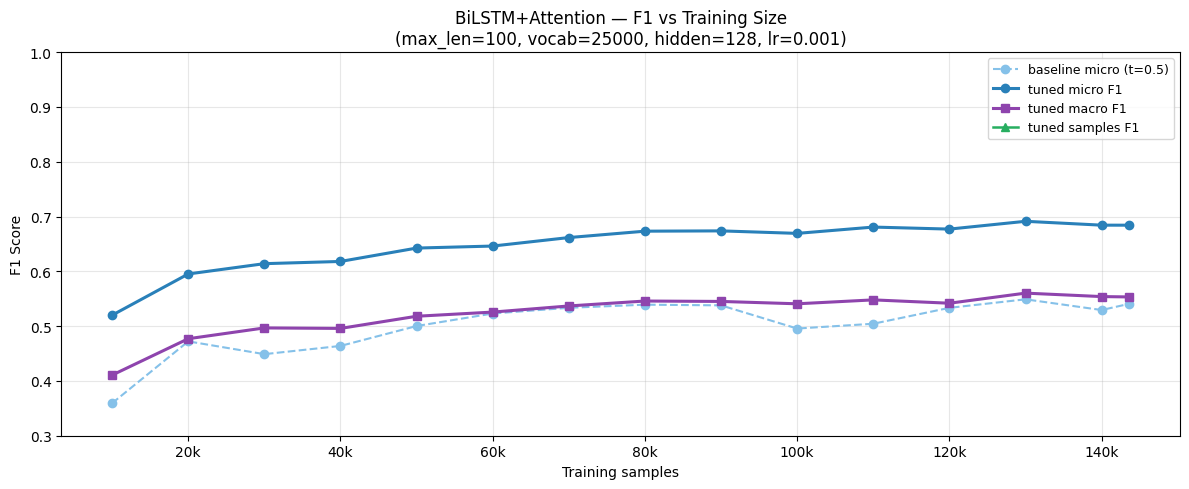

In [14]:
# Graph 1: F1 vs train size — baseline micro, tuned micro, tuned macro, tuned samples
plot_df = summary_df.sort_values('train_size').copy()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(plot_df['train_size'], plot_df['baseline_micro_f1'],
        marker='o', linestyle='--', color='#85c1e9', linewidth=1.5, label='baseline micro (t=0.5)')
ax.plot(plot_df['train_size'], plot_df['tuned_micro_f1'],
        marker='o', color='#2980b9', linewidth=2.2, label='tuned micro F1')
ax.plot(plot_df['train_size'], plot_df['tuned_macro_f1'],
        marker='s', color='#8e44ad', linewidth=2.2, label='tuned macro F1')
ax.plot(plot_df['train_size'], plot_df['tuned_samples_f1'],
        marker='^', color='#27ae60', linewidth=1.8, label='tuned samples F1')

ax.set_title(
    f'BiLSTM+Attention — F1 vs Training Size\n'
    f'(max_len={MAX_LEN}, vocab={MAX_VOCAB}, hidden={HIDDEN}, lr={LR})'
)
ax.set_xlabel('Training samples')
ax.set_ylabel('F1 Score')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
ax.set_ylim(0.3, 1.0)
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'graph_01_f1_vs_size.png', dpi=150)
plt.show()

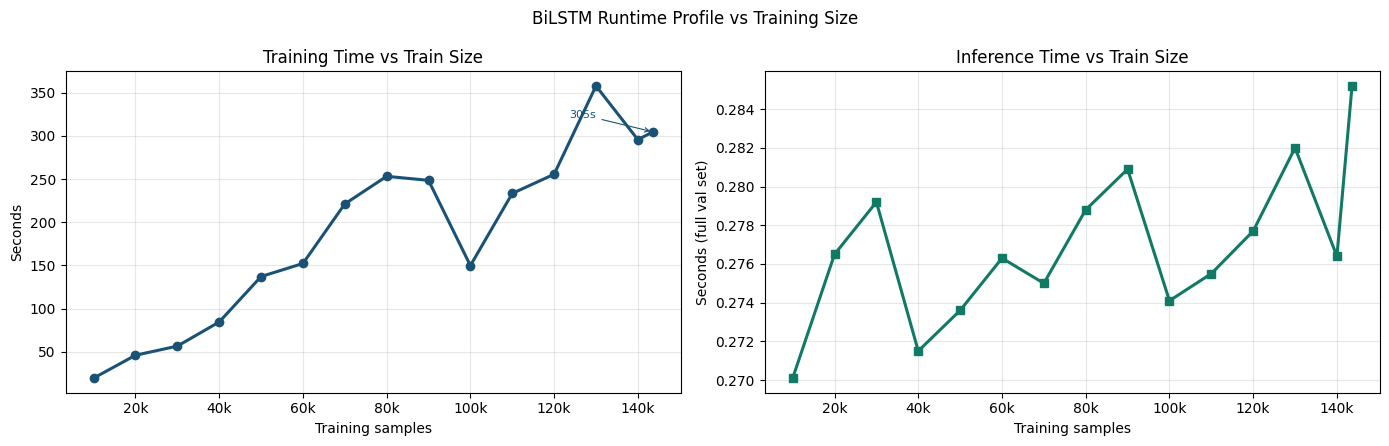

In [15]:
# Graph 2: Training and inference time vs train size (two subplots)
plot_df = summary_df.sort_values('train_size').copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(plot_df['train_size'], plot_df['train_time_s'],
         marker='o', color='#1a5276', linewidth=2.2)
if len(plot_df) > 0:
    fr = plot_df.iloc[-1]
    ax1.annotate(
        f"{fr['train_time_s']:.0f}s",
        (fr['train_size'], fr['train_time_s']),
        xytext=(-60, 10), textcoords='offset points', fontsize=8, color='#1a5276',
        arrowprops=dict(arrowstyle='->', color='#1a5276', lw=0.8),
    )
ax1.set_title('Training Time vs Train Size')
ax1.set_xlabel('Training samples')
ax1.set_ylabel('Seconds')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
ax1.grid(alpha=0.3)

ax2.plot(plot_df['train_size'], plot_df['inference_time_s'],
         marker='s', color='#117a65', linewidth=2.2)
ax2.set_title('Inference Time vs Train Size')
ax2.set_xlabel('Training samples')
ax2.set_ylabel('Seconds (full val set)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
ax2.grid(alpha=0.3)

fig.suptitle('BiLSTM Runtime Profile vs Training Size', fontsize=12)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'graph_02_runtime_vs_size.png', dpi=150)
plt.show()

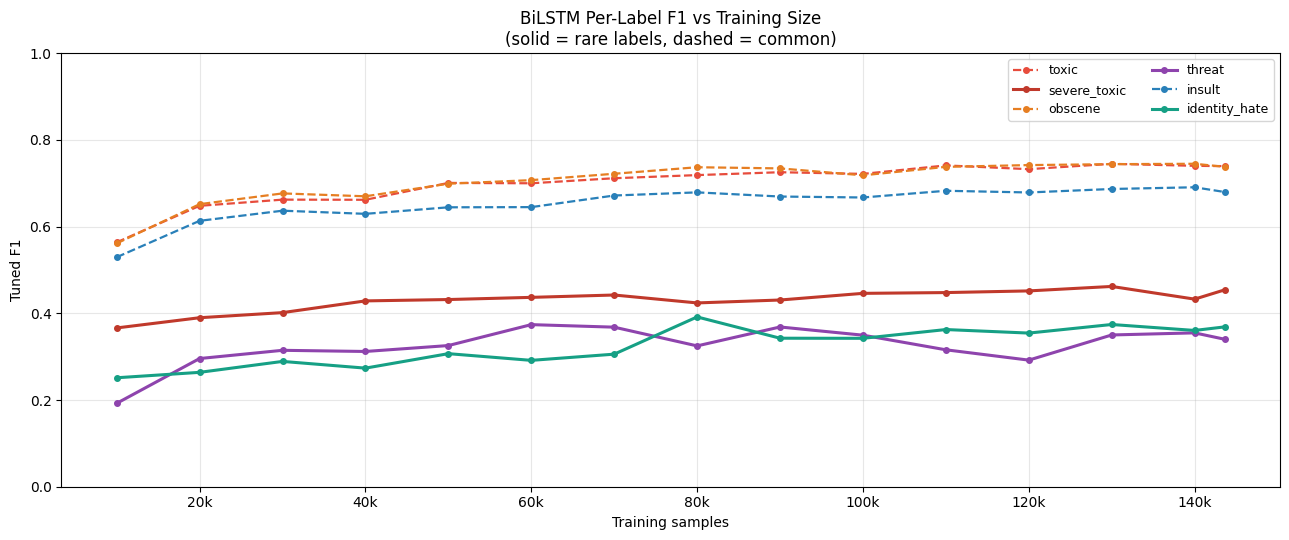

In [16]:
# Graph 3: Per-label F1 vs train size
if not per_label_all.empty:
    fig, ax = plt.subplots(figsize=(13, 5.5))
    for label in LABEL_COLUMNS:
        ldf = per_label_all[per_label_all['label'] == label].sort_values('train_size')
        ax.plot(
            ldf['train_size'], ldf['f1'],
            marker='o', markersize=4,
            linewidth=2.2 if label in RARE_LABELS else 1.6,
            linestyle='-' if label in RARE_LABELS else '--',
            color=LABEL_COLORS[label], label=label,
        )
    ax.set_title('BiLSTM Per-Label F1 vs Training Size\n(solid = rare labels, dashed = common)')
    ax.set_xlabel('Training samples')
    ax.set_ylabel('Tuned F1')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
    ax.set_ylim(0, 1.0)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, ncol=2)
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / 'graph_03_per_label_f1_vs_size.png', dpi=150)
    plt.show()

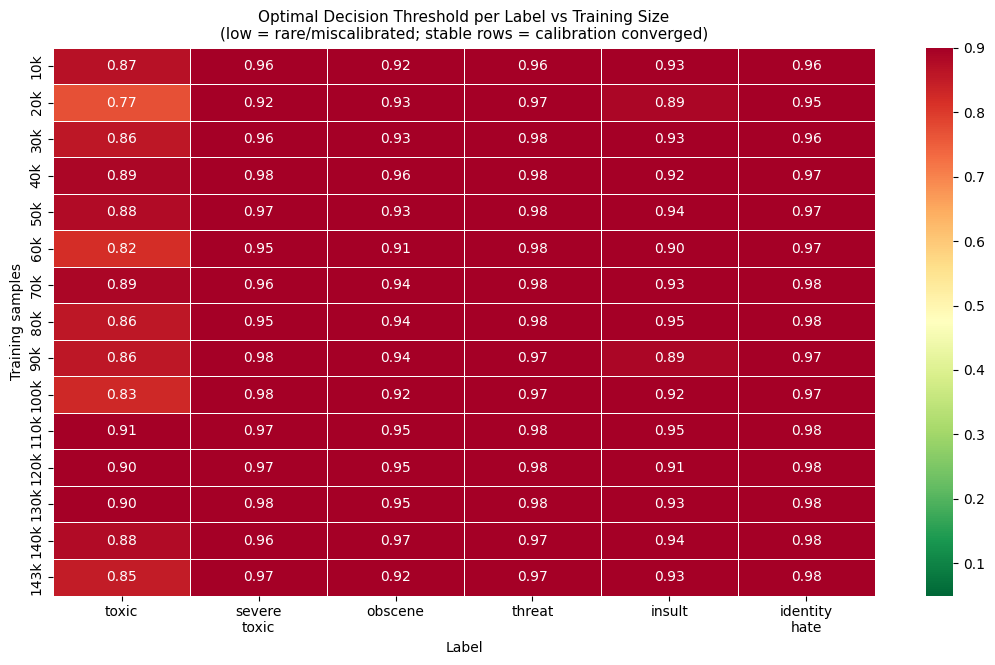

In [17]:
# Graph 5: Decision-threshold heatmap
# Low threshold = model systematically under-predicts that label at t=0.5.
# Stable rows = probability calibration has converged with more data.
if not thresholds_all.empty:
    sizes_sorted = sorted(thresholds_all['train_size'].unique())
    labels_order = list(LABEL_COLUMNS)
    heatmap_data = pd.DataFrame(index=sizes_sorted, columns=labels_order, dtype=float)
    for size in sizes_sorted:
        sub = thresholds_all[thresholds_all['train_size'] == size].set_index('label')
        for label in labels_order:
            if label in sub.index:
                heatmap_data.loc[size, label] = float(sub.loc[label, 'best_threshold'])

    fig, ax = plt.subplots(figsize=(11, max(5, len(sizes_sorted) * 0.45)))
    sns.heatmap(
        heatmap_data.astype(float), annot=True, fmt='.2f', cmap='RdYlGn_r',
        vmin=0.05, vmax=0.90, linewidths=0.4, linecolor='white', ax=ax,
        xticklabels=[l.replace('_', '\n') for l in labels_order],
        yticklabels=[f'{int(s/1000)}k' for s in sizes_sorted],
    )
    ax.set_title(
        'Optimal Decision Threshold per Label vs Training Size\n'
        '(low = rare/miscalibrated; stable rows = calibration converged)',
        fontsize=11,
    )
    ax.set_xlabel('Label')
    ax.set_ylabel('Training samples')
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / 'graph_05_threshold_heatmap.png', dpi=150)
    plt.show()

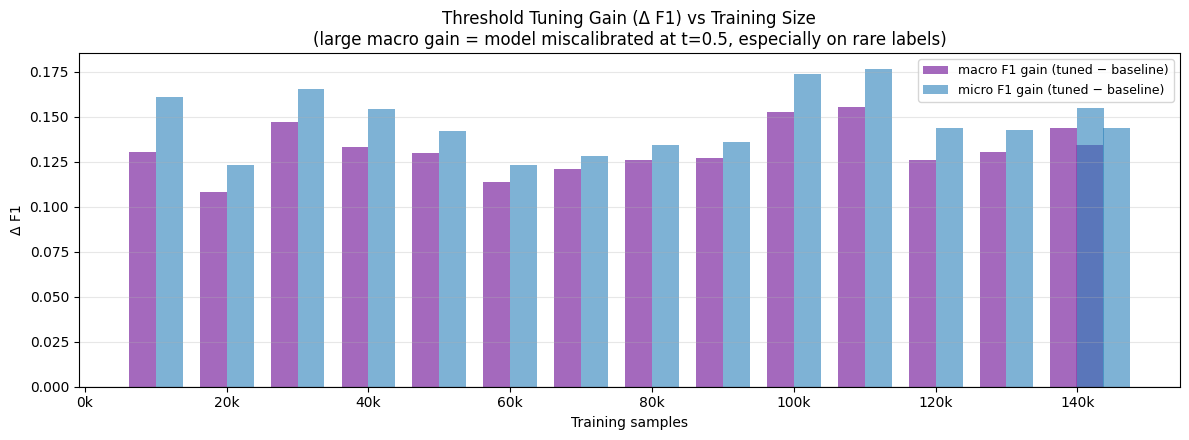

In [18]:
# Graph 6: Threshold tuning gain (tuned - baseline F1)
# Large gain = model miscalibrated at t=0.5; BiLSTM typically shows high gain on rare labels.
plot_df = summary_df.sort_values('train_size').copy()
plot_df['gain_macro'] = plot_df['tuned_macro_f1'] - plot_df['baseline_macro_f1']
plot_df['gain_micro'] = plot_df['tuned_micro_f1'] - plot_df['baseline_micro_f1']

fig, ax = plt.subplots(figsize=(12, 4.5))
x_pos  = np.array(plot_df['train_size'].values, dtype=float)
width  = float(x_pos[1] - x_pos[0]) * 0.38 if len(x_pos) > 1 else 4000.0

ax.bar(x_pos - width / 2, plot_df['gain_macro'], width=width,
       color='#8e44ad', alpha=0.8, label='macro F1 gain (tuned − baseline)')
ax.bar(x_pos + width / 2, plot_df['gain_micro'], width=width,
       color='#2980b9', alpha=0.6, label='micro F1 gain (tuned − baseline)')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_title(
    'Threshold Tuning Gain (Δ F1) vs Training Size\n'
    '(large macro gain = model miscalibrated at t=0.5, especially on rare labels)'
)
ax.set_xlabel('Training samples')
ax.set_ylabel('Δ F1')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'graph_06_tuning_gain_vs_size.png', dpi=150)
plt.show()

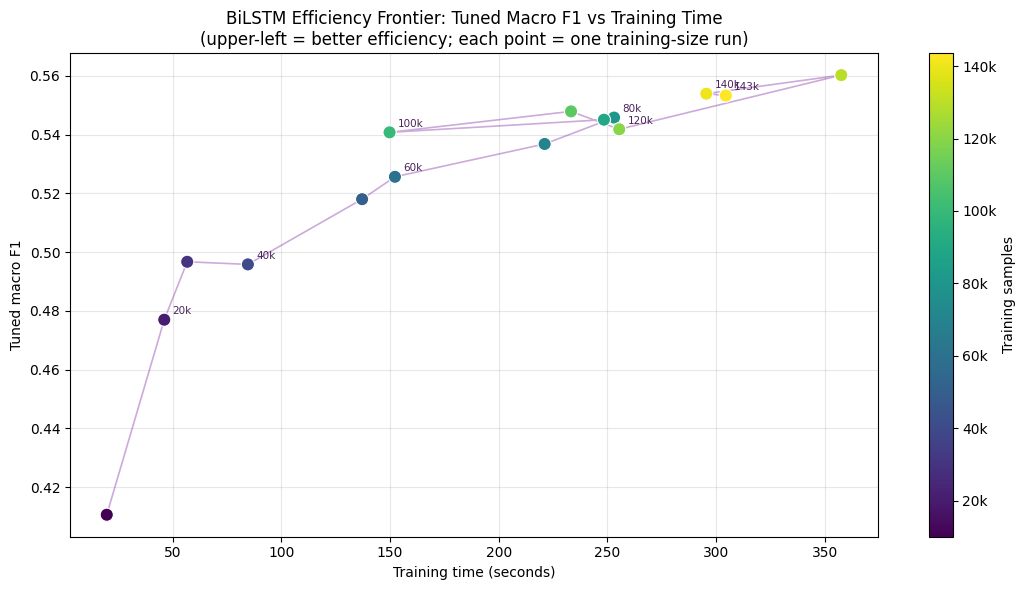

In [19]:
# Graph 7: Efficiency frontier — macro F1 vs training time (BiLSTM only)
# Each point is one training-size run; colour encodes dataset size.
# Upper-left = better efficiency (higher F1, shorter training time).
plot_df = summary_df.sort_values('train_size').copy()

fig, ax = plt.subplots(figsize=(11, 6))

sc = ax.scatter(
    plot_df['train_time_s'], plot_df['tuned_macro_f1'],
    c=plot_df['train_size'], cmap='viridis', s=90, zorder=5,
    edgecolors='white', linewidth=0.8,
)
ax.plot(plot_df['train_time_s'], plot_df['tuned_macro_f1'],
        color='#8e44ad', linewidth=1.2, alpha=0.45)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Training samples')
cbar.formatter = mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k')
cbar.update_ticks()

for _, row_r in plot_df.iterrows():
    size_k = int(row_r['train_size'] / 1000)
    if size_k % 20 == 0 or row_r['train_size'] == plot_df['train_size'].max():
        ax.annotate(
            f'{size_k}k', (row_r['train_time_s'], row_r['tuned_macro_f1']),
            xytext=(6, 4), textcoords='offset points', fontsize=7.5, color='#4a235a',
        )

ax.set_title(
    'BiLSTM Efficiency Frontier: Tuned Macro F1 vs Training Time\n'
    '(upper-left = better efficiency; each point = one training-size run)'
)
ax.set_xlabel('Training time (seconds)')
ax.set_ylabel('Tuned macro F1')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'graph_07_efficiency_frontier.png', dpi=150)
plt.show()

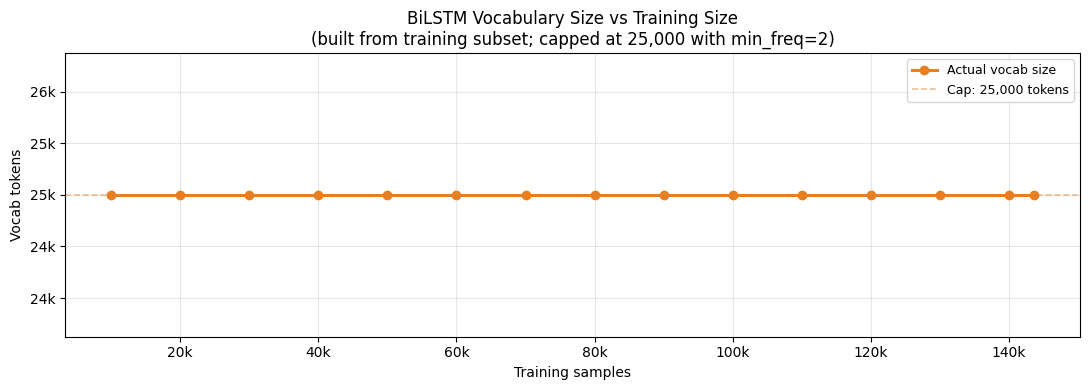

In [20]:
# Graph 9: Vocab size vs training size
# Unique to BiLSTM — transformers use a fixed pretrained vocabulary.
# Shows diminishing returns in vocabulary coverage as training data grows.
plot_df = summary_df.sort_values('train_size').copy()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(plot_df['train_size'], plot_df['vocab_size'],
        marker='o', color='#e67e22', linewidth=2.2, label='Actual vocab size')
ax.axhline(MAX_VOCAB, color='#e67e22', linestyle='--', linewidth=1.2, alpha=0.5,
           label=f'Cap: {MAX_VOCAB:,} tokens')
ax.set_title(
    f'BiLSTM Vocabulary Size vs Training Size\n'
    f'(built from training subset; capped at {MAX_VOCAB:,} with min_freq={MIN_FREQ})'
)
ax.set_xlabel('Training samples')
ax.set_ylabel('Vocab tokens')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{int(y/1000)}k'))
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'graph_09_vocab_vs_size.png', dpi=150)
plt.show()

In [21]:
import IPython.display as ipd

key_cols = [
    'train_size', 'actual_train_samples', 'vocab_size',
    'epochs_ran', 'best_epoch', 'early_stopped',
    'baseline_micro_f1', 'baseline_macro_f1',
    'tuned_micro_f1',    'tuned_macro_f1',
    'train_time_s',      'inference_time_s',
]

print('=== BiLSTM Sweep Summary ===')
ipd.display(summary_df[key_cols].round(4))

print('\n=== Full-dataset per-label metrics ===')
full_size = summary_df['train_size'].max()
ipd.display(
    per_label_all[per_label_all['train_size'] == full_size]
    [['label', 'precision', 'recall', 'f1', 'roc_auc']]
    .round(4).reset_index(drop=True)
)

print('\n=== Full-dataset optimal thresholds ===')
ipd.display(
    thresholds_all[thresholds_all['train_size'] == full_size]
    [['label', 'best_threshold', 'best_f1_on_val']]
    .reset_index(drop=True)
)

best_run = summary_df.loc[summary_df['tuned_macro_f1'].idxmax()]
print(f'\n=== Best run ===')
print(f'  train_size:    {int(best_run["train_size"]):,}')
print(f'  tuned_macro:   {best_run["tuned_macro_f1"]:.4f}')
print(f'  tuned_micro:   {best_run["tuned_micro_f1"]:.4f}')
print(f'  best_epoch:    {int(best_run["best_epoch"])}')
print(f'  train_time_s:  {best_run["train_time_s"]:.0f}s')
print(f'  vocab_size:    {int(best_run["vocab_size"]):,}')

=== BiLSTM Sweep Summary ===


,train_size,actual_train_samples,vocab_size,epochs_ran,best_epoch,early_stopped,baseline_micro_f1,baseline_macro_f1,tuned_micro_f1,tuned_macro_f1,train_time_s,inference_time_s
0,10000,10000,25000,9,6,True,0.3593,0.2803,0.5199,0.4106,19.74,0.2701
1,20000,20000,25000,11,8,True,0.4722,0.3690,0.5952,0.4770,46.19,0.2765
2,30000,30000,25000,9,6,True,0.4488,0.3496,0.6140,0.4967,56.75,0.2792
3,40000,40000,25000,10,7,True,0.4639,0.3626,0.6180,0.4958,84.66,0.2715
4,50000,50000,25000,13,10,True,0.5002,0.3884,0.6424,0.5180,137.20,0.2736
5,60000,60000,25000,12,9,True,0.5230,0.4119,0.6461,0.5256,152.30,0.2763
6,70000,70000,25000,15,14,False,0.5335,0.4156,0.6616,0.5368,221.16,0.2750
7,80000,80000,25000,15,14,False,0.5391,0.4199,0.6733,0.5458,253.10,0.2788
8,90000,90000,25000,13,10,True,0.5379,0.4181,0.6738,0.5451,248.44,0.2809
9,100000,100000,25000,7,4,True,0.4956,0.3881,0.6692,0.5408,149.83,0.2741



=== Full-dataset per-label metrics ===


,label,precision,recall,f1,roc_auc
0,toxic,0.7450,0.7338,0.7394,0.9568
1,severe_toxic,0.3453,0.6625,0.4540,0.9849
2,obscene,0.7396,0.7361,0.7378,0.9696
3,threat,0.2525,0.5208,0.3401,0.9655
4,insult,0.6568,0.7043,0.6797,0.9690
5,identity_hate,0.3553,0.3830,0.3686,0.9535



=== Full-dataset optimal thresholds ===


,label,best_threshold,best_f1_on_val
0,toxic,0.85,0.739374
1,severe_toxic,0.97,0.453961
2,obscene,0.92,0.737841
3,threat,0.97,0.340136
4,insult,0.93,0.679731
5,identity_hate,0.98,0.368601



=== Best run ===
  train_size:    130,000
  tuned_macro:   0.5602
  tuned_micro:   0.6913
  best_epoch:    10
  train_time_s:  358s
  vocab_size:    25,000
